In [1]:
from operator import index

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import ticker
from matplotlib.ticker import (MultipleLocator, LinearLocator, AutoMinorLocator)
#from mpl_toolkits.axisartist.axislines import Subplot
from scipy.integrate import odeint

In [2]:
#Param
d1 = 1.35e-7 # min N-unit inverse

# Parameters for phagocytes
k1 = 4.9956e7 #N-unit Kg / min pg
k2 = 12.94907 # ND
h1 = 1693.9509 #pg/mL
h2 = 0.07212   # pg/mL
h3 = 147.68    # pg/mL
d2 = 0.1439   # 1/min

# Parameters for TGF beta
k3 = 1.546*1e-9 # mL/pg N-unit min
k4 = 0.5     # mL/pg min
h4 = 500#*1e6/100     # pg / mL
d3 = 0.031777 # 1/min

# Parameters for TNF alpha
h5 = 550e4   # N-unit
h6 = 0.1589  # pg/mL
k5 = 25.5194 # pg/mL min
k6 = 3.5514e4 # pg/mL min
h7 = 1.5495e3 # pg/mL
d4 = 0.0293 #0.0307/1   #mL/pg min

# Parameters for IL-10
b1 = 1187.2 # pg/mL min
k7 = 267480 #  pg/mL min
h8 = 8.0506e7 # N-unit
k8 = 43875 #  pg/mL min
h9 = 0.38  # pg/mL
d5 = 98.932 # 1/min
h10 = 791.27 #pg/mL

# Parameters for CRH
b2 = 0.001 # pg/mL min
k9 = 6.84e9 # pg/ml min
k10 = 1.7558e9#/(1e12))*(100^2) #(mL/pg^2)
k11 = 0.0667 # 1/min
d6 = 0.032 #1/min

# Parameters for ACTH
k12 = 2.3688e4 #1/min
k13 = 1.7778e5#/1e6)*100 #mL/pg
k14 = 112 #pg/mL min
h11 = 80 #pg/mL
d7  = 0.016 # 1/min

# Parameters for Cortisol
k15 = 4.2541e-04#*1e6/100 #pg mL / mL min pg
k16 = 12 # pg/mL
d8  = 0.0266 #1/min

# Parameters for the circadian rhythm
alpha = 300 #min
k     = 5 #ND
beta = 950 #min
L = 6 #ND
eps = 0.01 #ND
delta = 70#76.37 #min
T = 1440 # min
Nc = 1.9168


param_nolog = [d1,
k1,k2,h1,h2,h3,d2,
k3,k4,h4,d3,
h5,h6,k5,k6,h7,d4,
b1,k7,h8,k8,h9,d5,h10,
b2,k9,k10,k11,d6,
k12,k13,k14,h11,d7,
k15,k16,d8,
alpha, k, beta, L, eps, delta, T, Nc
 ]


#Initial Conditions
endo_0 = 0
phag_0 = 0
TGFB_0 = 0.004/d3
TNF_0  = 0
IL10_0 = b1*h10/(d5*h10-b1)
CRH_0  = 2
ACTH_0 = 150
cort_0 = 1.9


IC = [endo_0, phag_0, TGFB_0, TNF_0, IL10_0, CRH_0, ACTH_0, cort_0]

In [3]:
def ITIS(y,t,param):
 endo,phag,TGFB,TNF,IL10,CRH,ACTH,cort = y

 (d1,
k1,k2,h1,h2,h3,d2,
k3,k4,h4,d3,
h5,h6,k5,k6,h7,d4,
b1,k7,h8,k8,h9,d5,h10,
b2,k9,k10,k11,d6,
k12,k13,k14,h11,d7,
k15,k16,d8,
alpha, k, beta, L, eps, delta, T, Nc) = np.exp(param)

#Circadian Rhythm
 tm = (t * 60 - delta) % T
 R_1 = tm**k / (tm**k + alpha**k)
 R_2 = ((T - tm)**L) / ((T - tm)**L + beta**L)
 R_func = Nc*(R_1*R_2 + eps)

#Other things
 phag1 = 1 + k2 * (TNF / (h1 + TNF))
 phag2 = (h2 / (h2+TGFB)) * (h3 / (h3 + IL10))

 tnf1 = (phag / (h5 + phag)) * (h6**4 / (h6**4 + TGFB**4))
 tnf2 = k5 + k6 * (TNF / (h7 + TNF))

 il10_1 = k7 * (phag**3 / (h8**3 + phag**3)) + k8 * (TGFB**6 / (h9**6 + TGFB**6))

 crh1 = R_func * k9 * (CRH / (1+k10*cort**2)) ##[RESOLVE]

#Differential equations
 dendo = -d1 * endo * phag
 dphag = k1 * (phag1 * phag2) * endo - d2 * phag
 dTGFB = k3 * phag + k4 * cort / (h4 + cort) - d3 * TGFB
 dTNF = tnf1 * tnf2 - d4 * (TNF**2)
 dIL10 = b1 + il10_1 - d5 * (h10 / (h10 + IL10)) * IL10
 dCRH = b2 * 60 + crh1 * 60 + k11 * TNF - d6 * CRH * 60
 dACTH = k12 * (CRH / (1 + k13 * cort)) * 60 + k14 * (TNF**2 / (h11**2 + TNF**2)) - d7 * ACTH * 60
 dcort = k15 * (ACTH **2 / (1 + k16 * TGFB)) * 60 - d8 * cort * 60

 dy = [dendo,dphag,dTGFB,dTNF,dIL10,dCRH,dACTH,dcort]
 return dy

In [4]:
##MAIN
param = np.log(param_nolog) #log scale params for sensitivity analysis
#tspace
tstart = 0
tend = 80 ##Might want to make this longer. Goes up to injection time detailed in paper for now
dt = .1

tspace = np.arange(tstart,tend,dt)

n_time = 200
tplot = np.linspace(tstart,tend,n_time)

y = odeint(ITIS,IC,tspace,args=(param,))

endo = np.interp(tplot,tspace,y.T[0]) #RESOLVE T?
phag = np.interp(tplot,tspace,y.T[1])
TGFB = np.interp(tplot,tspace,y.T[2])
TNF = np.interp(tplot,tspace,y.T[3])
IL10 = np.interp(tplot,tspace,y.T[4])
CRH = np.interp(tplot,tspace,y.T[5])
ACTH = np.interp(tplot,tspace,y.T[6])
cort = np.interp(tplot,tspace,y.T[7])

solution = [endo,phag,TGFB,TNF,IL10,CRH,ACTH,cort]

stateTitles = ["Endotoxin","Phagocytes","TGF-B","TNF-a","IL-10","CRH", "ACTH", "Cortisol"]

#Recalculations for plotting
tm = (tspace * 60 - delta) % T
R_1 = tm**k / (tm**k + alpha**k)
R_2 = ((T - tm) ** L) / ((T - tm) **L + beta**L)
R_func = Nc * (R_1*R_2 + eps)

tplot = tplot - tplot[0]


In [5]:
#Pulling some data:
def get_range(x):
    minx = round(min(x),3)
    maxx = round(max(x),3)
    return [minx,maxx]

print(get_range(CRH), '\n', get_range(ACTH), '\n', get_range(cort))

[0.043, 297.559] 
 [4.856, 150.0] 
 [1.132, 45.763]


In [6]:
##SENSITIVITY ANALYSIS

h = 1e-6  #amount to perturb parameters
n_param = len(param)

Sensitivity_Mat = np.zeros((n_param, 8,
                            tplot.size))  ##Initialize shape of sensitivity matrix. This will contain sensitivites for 45 parameters relative to each 8 eqns, for 200 time points in tplot
for k in range(8):  #for each 8 equations...
 for i in range(n_param):  #calculate the relative sensitivity to each 45 parameters

  deltaparams = [float(theta) for theta in param]
  #params list that can be perturbed. Reset for each param
  deltaparams[i] = deltaparams[i] + h  #perturb each parameter OAT here.

  y_delta = odeint(ITIS, IC, tspace, args=(deltaparams,))  #solution before bolus injection with perturbed parameter

  solution2 = np.interp(tplot, tspace,
                        y_delta.T[k])  #store solutions to the equation k with perturbation in tplot sized space

  #Idea: Solve for everything needed. Store whatever can be reused. Solve finite differences.
  Sensitivity_Mat[i, k, :] = ((1 / h) * (np.subtract(solution2, solution[
   k])))  #for each parameter and each equation, append each finite differences approximation (200 total)

twonorms = np.zeros((45, 8))
for k in range(8):
 for i in range(n_param):
  twonorms[i, k] = np.power(sum(np.power(Sensitivity_Mat[i, k, :], 2)), 1 / 2)

twonorms_Long = twonorms.flatten()

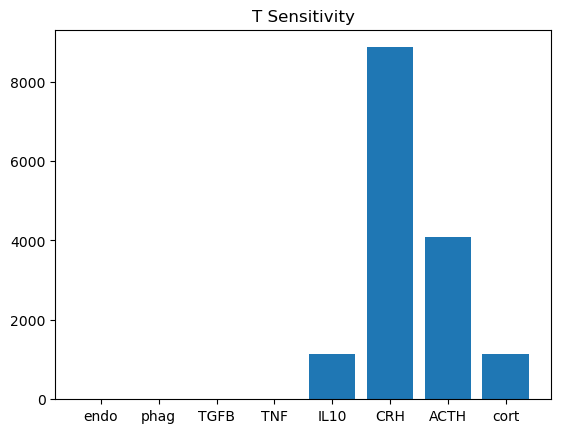

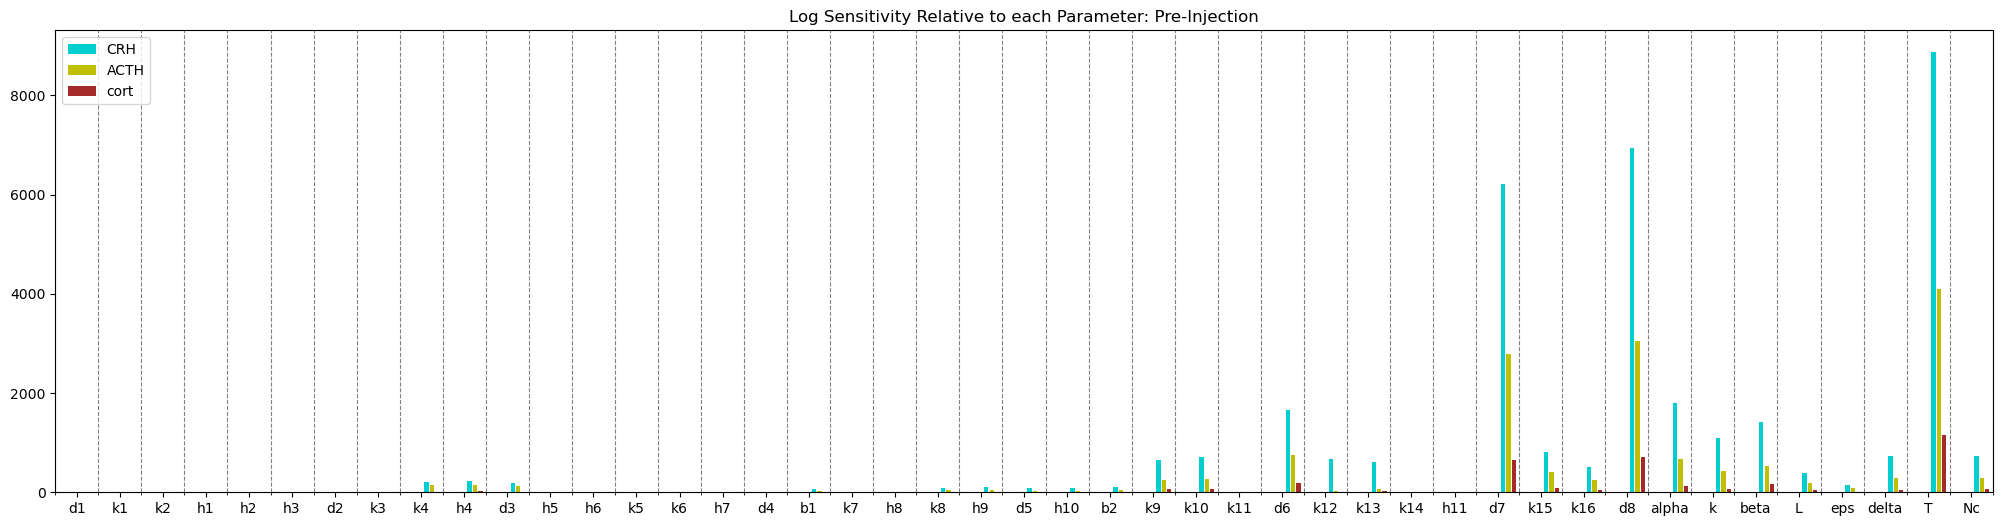

In [7]:

##PLOTTING

paramtitles = ['d1',
               'k1', 'k2', 'h1', 'h2', 'h3', 'd2',
               'k3', 'k4', 'h4', 'd3',
               'h5', 'h6', 'k5', 'k6', 'h7', 'd4',
               'b1', 'k7', 'h8', 'k8', 'h9', 'd5', 'h10',
               'b2', 'k9', 'k10', 'k11', 'd6',
               'k12', 'k13', 'k14', 'h11', 'd7',
               'k15', 'k16', 'd8',
               'alpha', 'k', 'beta', 'L', 'eps', 'delta', 'T', 'Nc']

statetitles = ["Endotoxin", "Phagocytes", "TGF-B", "TNF-a", "IL-10", "CRH", "ACTH", "Cortisol"]
statetitles_Short = ['endo', 'phag', 'TGFB', 'TNF', 'IL10', 'CRH', 'ACTH', 'cort']

##Bar plot for all sensitivities of one param relative to each state..
param_I = 43
plt.bar(statetitles_Short, twonorms[param_I, :])
plt.title(paramtitles[param_I] + " Sensitivity")
plt.show()

##Mega graph. All sensitivites relative to states of interest

paramtitles_empty = [n for n in range(0, n_param * 8)]

fig, axs = plt.subplots(figsize=(25, 6))

plt.grid(which='minor', axis='x', ls='--', color='gray')

colors = ['blue', 'orange', 'green', 'red', 'blueviolet', 'darkturquoise', 'y', 'brown']
for i in range(5, 8):
 axs.bar(paramtitles_empty[i::8], twonorms_Long[i::8], label=statetitles_Short[i], color=colors[i])

axs.set_xticks([8 * n + 4 for n in range(n_param)], labels=paramtitles)
plt.legend()

axs.set_xlim([0, n_param * 8])

axs.xaxis.set_minor_locator(MultipleLocator(8))
##reshape graph or switch to multiple?

plt.title('Log Sensitivity Relative to each Parameter: Pre-Injection')
#plt.savefig('C:\\Users\\ayres\\Desktop\\RESEARCH, GRANTS, LIFE!!!!\\Cardiovascular Research Spring 2025\\THESIS MATERIALS\\L2normsPreInj.png')
plt.show()

In [8]:
IC2 = np.zeros(8)
for i in range(8):
    IC2[i] = solution[i][-1]

IC2

array([ 0.        ,  0.        ,  0.1595967 ,  0.        , 14.68266827,
       41.49891056, 39.97751646, 11.29827208])